In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx


from scene import create_scene_graph, reset_graph, check_completion, get_completion_stats
from rl_functions import get_state, sample_step, reward
from config import START_POSITION, MAX_STEPS_PER_EPISODE, GRID_SIZE

In [ ]:
def visualize_episode_matplotlib(graph, visited_path, final_pos):
    fig, ax = plt.subplots(figsize=(10, 10))
    
    for x in range(GRID_SIZE):
        for y in range(GRID_SIZE):
            node = (x, y)
            data = graph.nodes[node]
            
            color = 'whitesmoke'
            alpha = 1.0
            
            if data.get('is_obstacle', False):
                color = 'black' 
            elif (x, y) == final_pos:
                color = 'red'   
            elif (x, y) in visited_path:
                color = 'limegreen' 
                alpha = 0.6
            
            rect = plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color=color, alpha=alpha, ec='gray')
            ax.add_patch(rect)

    ax.set_xlim(-0.6, GRID_SIZE - 0.4)
    ax.set_ylim(-0.6, GRID_SIZE - 0.4)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.set_aspect('equal')
    ax.set_title("Final State of the Episode (Matplotlib Viz)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

--- Starting Episode (Start: (0, 9)) ---
  [policy] s=(0, 9) (step 0):
    P(Left) = 0.2021
    P(Up) = 0.2897
    P(Right) = 0.0852
    P(Down) = 0.4231
  [sample_step] Chosen action: Left -> New Pos: (0, 9)


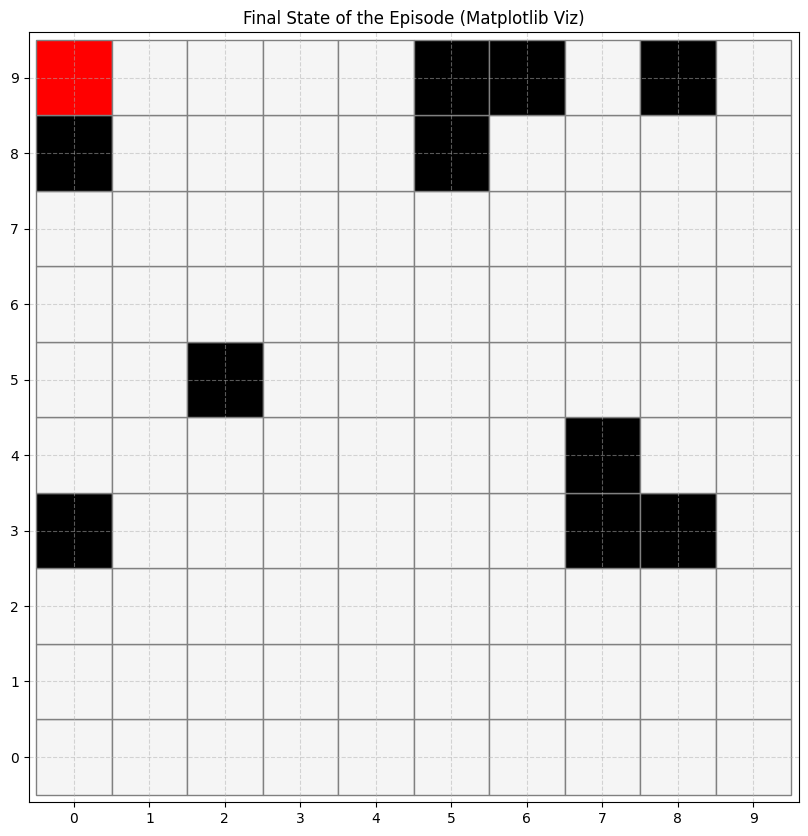

  [policy] s=(0, 9) (step 1):
    P(Left) = 0.2992
    P(Up) = 0.0264
    P(Right) = 0.1450
    P(Down) = 0.5294
  [sample_step] Chosen action: Right -> New Pos: (1, 9)


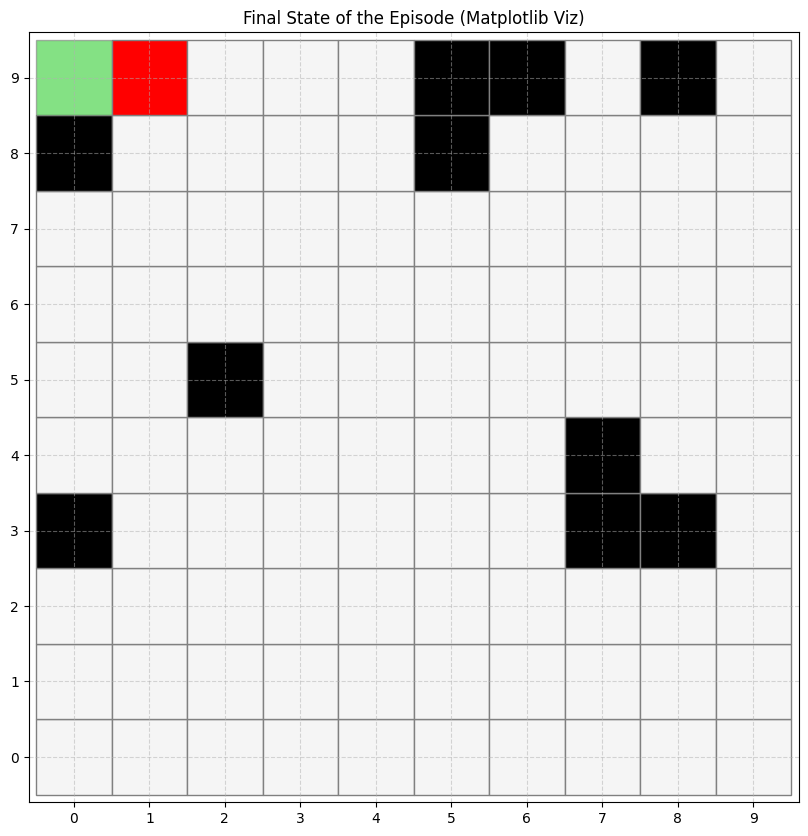

  [policy] s=(1, 9) (step 2):
    P(Left) = 0.2408
    P(Up) = 0.2941
    P(Right) = 0.1129
    P(Down) = 0.3521
  [sample_step] Chosen action: Down -> New Pos: (1, 8)


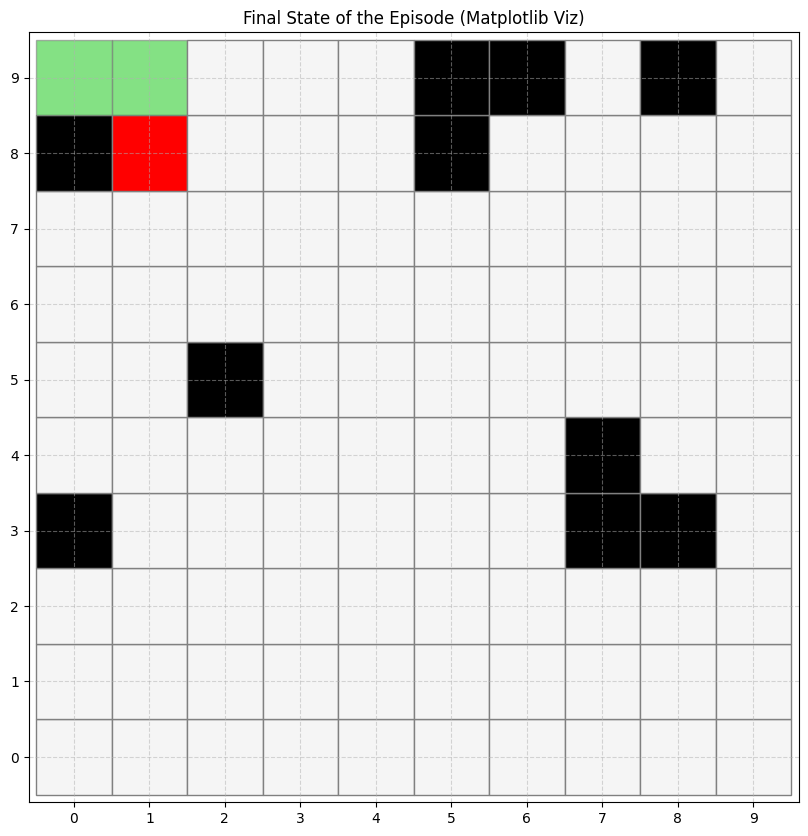

  [policy] s=(1, 8) (step 3):
    P(Left) = 0.1772
    P(Up) = 0.0157
    P(Right) = 0.3457
    P(Down) = 0.4614
  [sample_step] Chosen action: Down -> New Pos: (1, 7)


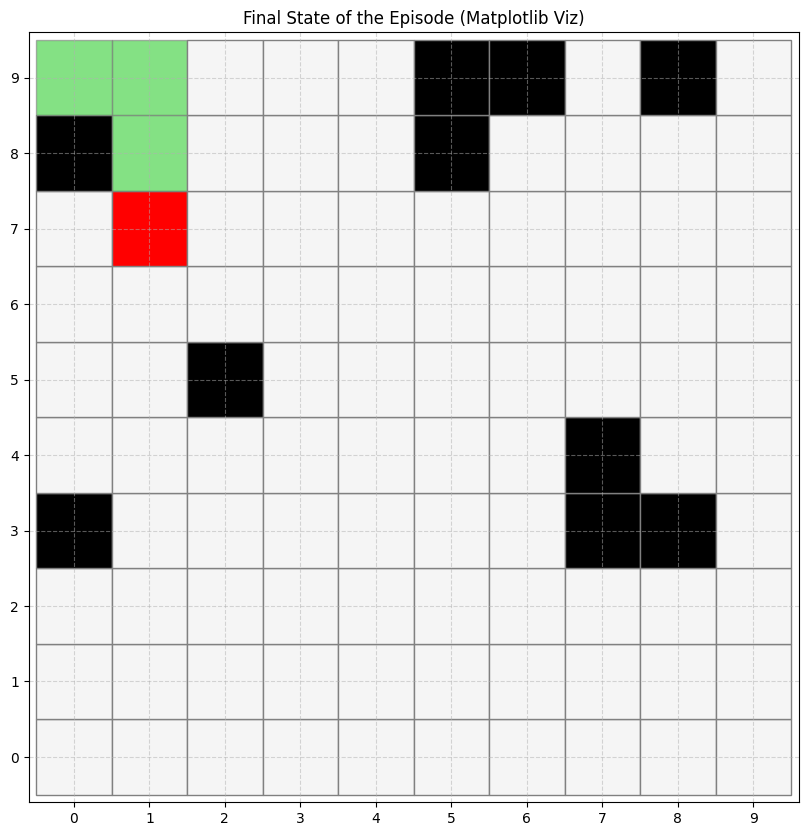

  [policy] s=(1, 7) (step 4):
    P(Left) = 0.1695
    P(Up) = 0.3263
    P(Right) = 0.3210
    P(Down) = 0.1832
  [sample_step] Chosen action: Up -> New Pos: (1, 8)


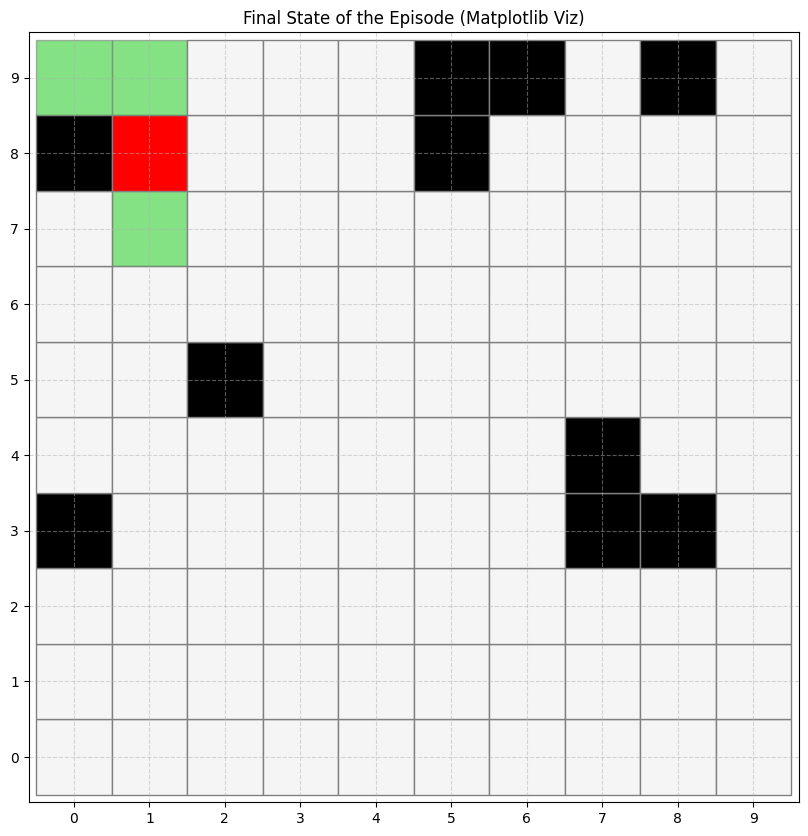

  [policy] s=(1, 8) (step 5):
    P(Left) = 0.2549
    P(Up) = 0.3614
    P(Right) = 0.0697
    P(Down) = 0.3139
  [sample_step] Chosen action: Right -> New Pos: (2, 8)


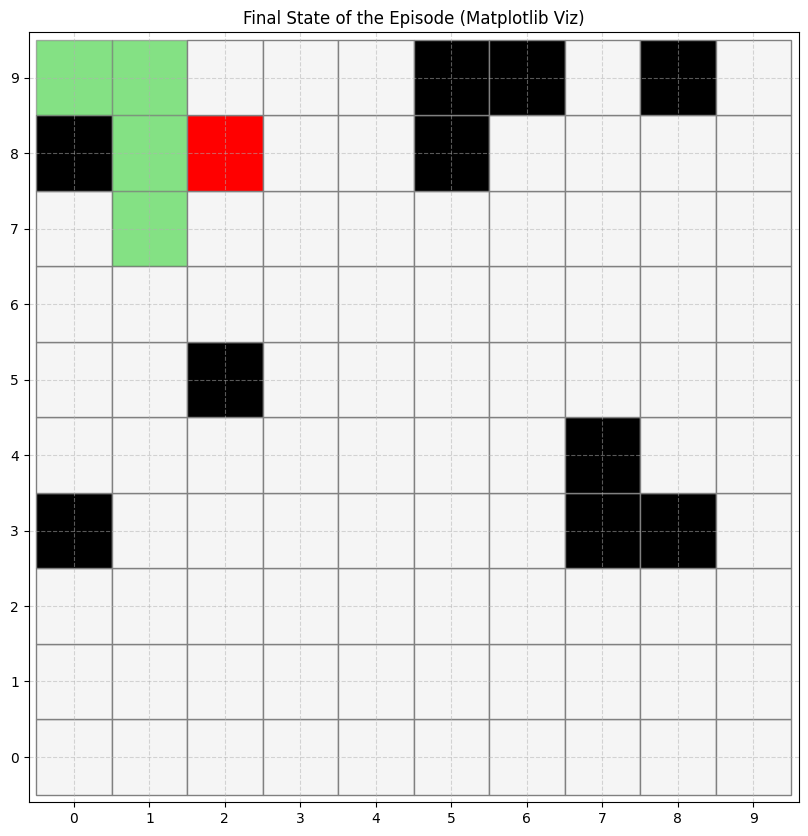

  [policy] s=(2, 8) (step 6):
    P(Left) = 0.0837
    P(Up) = 0.4669
    P(Right) = 0.1483
    P(Down) = 0.3011
  [sample_step] Chosen action: Right -> New Pos: (3, 8)


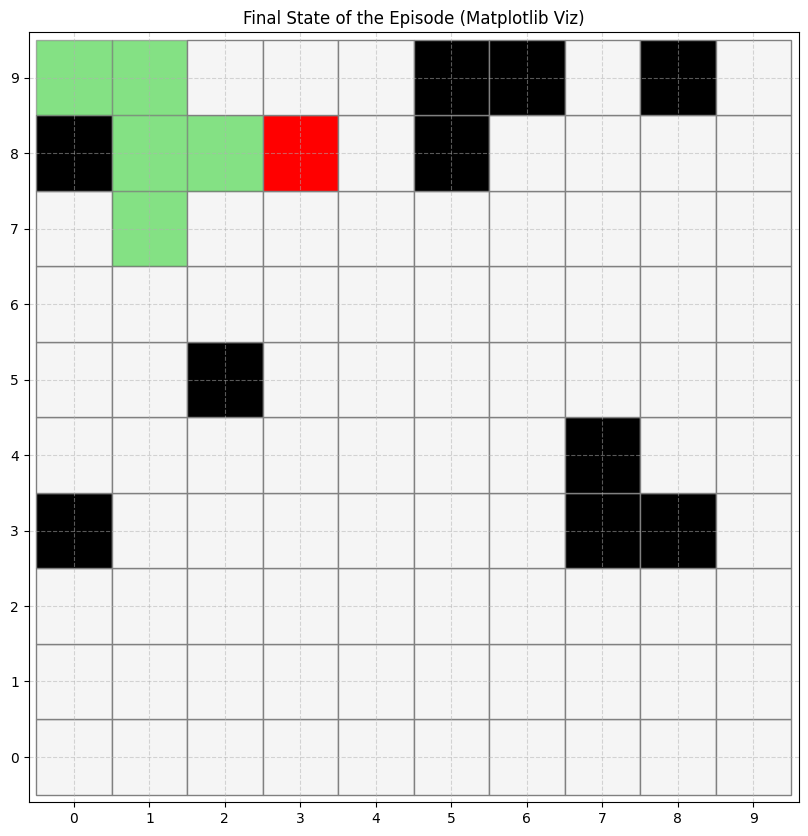

  [policy] s=(3, 8) (step 7):
    P(Left) = 0.2899
    P(Up) = 0.4872
    P(Right) = 0.1319
    P(Down) = 0.0910
  [sample_step] Chosen action: Down -> New Pos: (3, 7)


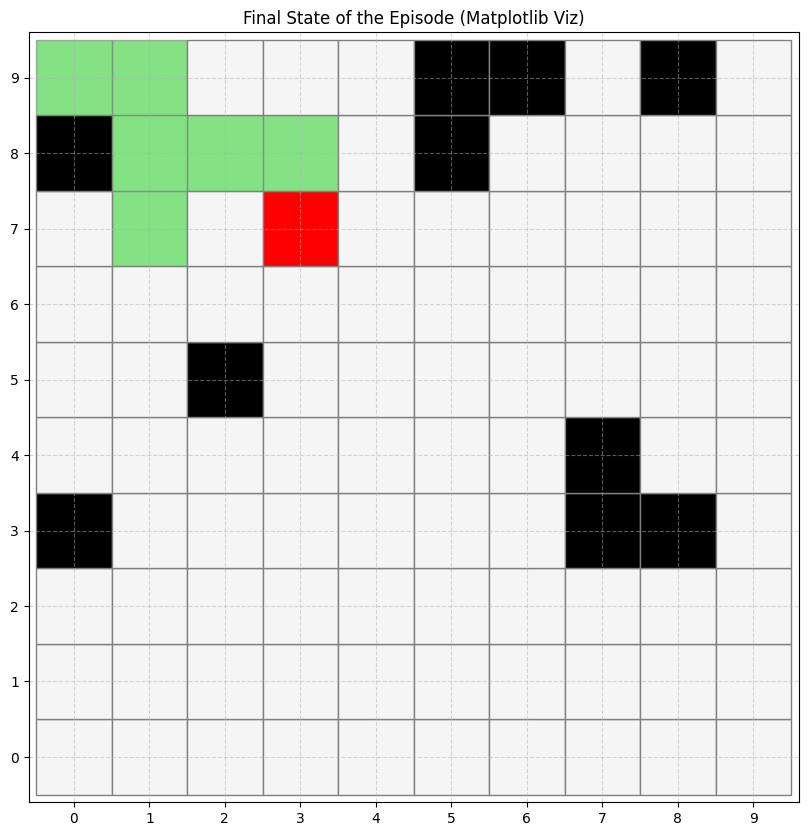

  [policy] s=(3, 7) (step 8):
    P(Left) = 0.3602
    P(Up) = 0.2468
    P(Right) = 0.1842
    P(Down) = 0.2088
  [sample_step] Chosen action: Left -> New Pos: (2, 7)


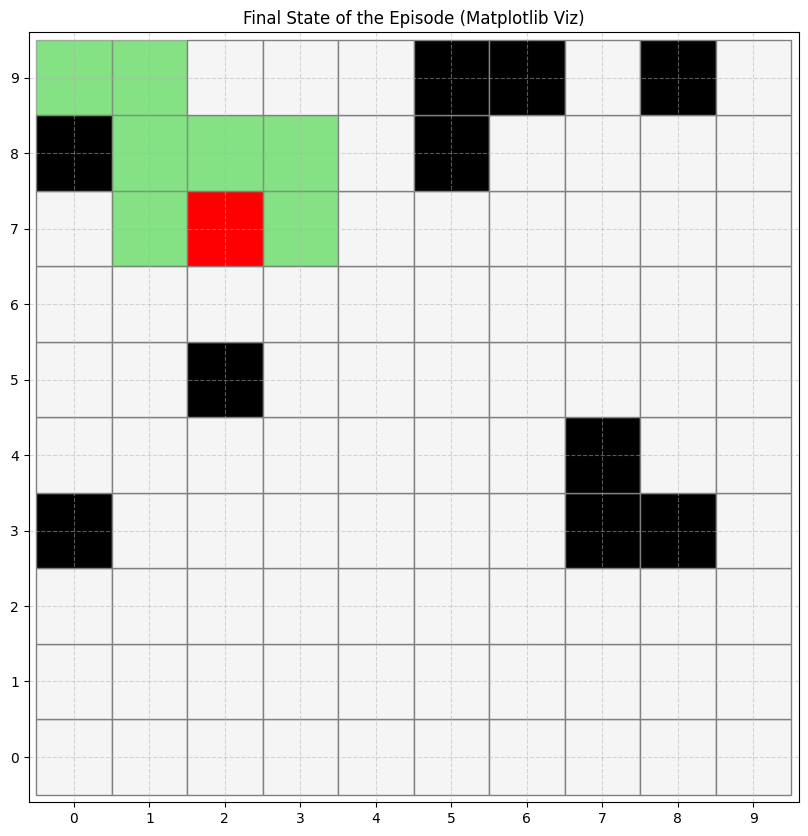

--- Episode Ended ---
Total Steps: 9
Total Reward (G): 6.00
Completion: 7.8% (7/90 cells)


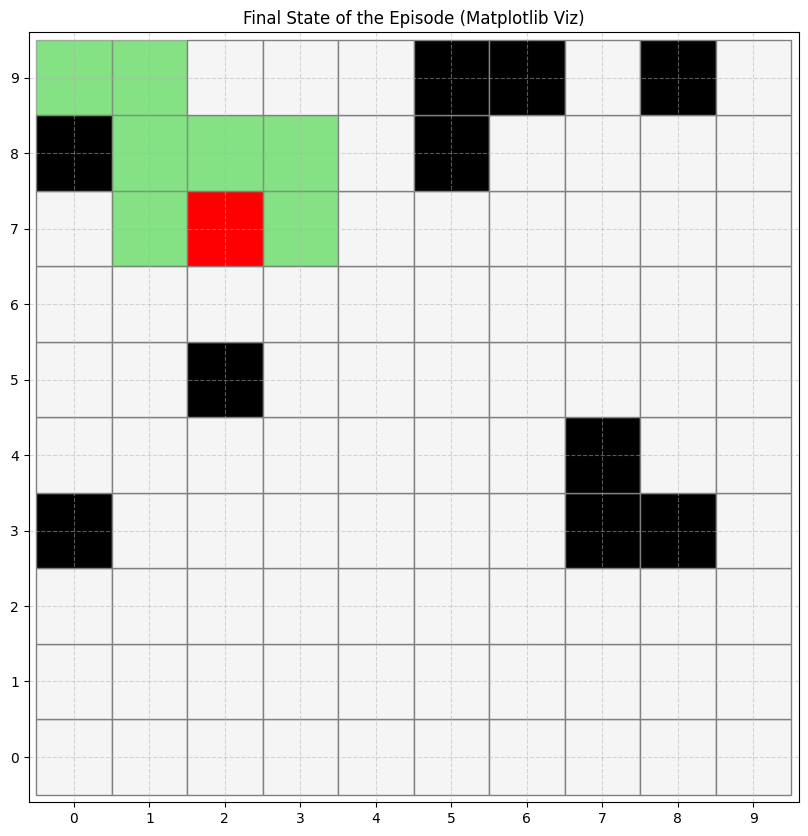

In [ ]:
graph = create_scene_graph(obstacle_prob=0.15)
reset_graph(graph)
state = get_state(graph, START_POSITION, steps=0)

total_reward = 0
path = [START_POSITION]

print(f"--- Starting Episode (Start: {START_POSITION}) ---")

for step_num in range(1, 10):
    r = reward(graph, state)
    total_reward += r
    
    state = sample_step(graph, state)
    
    current_pos = state['agent_pos']
    path.append(current_pos)
    
    if check_completion(graph):
        print(f"Goal: All free cells visited at step {step_num}!")
        break

    unique_visited = set(path)
    visualize_episode_matplotlib(graph, unique_visited, state['agent_pos'])

print(f"--- Episode Ended ---")
print(f"Total Steps: {state['steps']}")
print(f"Total Reward (G): {total_reward:.2f}")

stats = get_completion_stats(graph)
print(f"Completion: {stats['percentage']:.1f}% ({stats['visited']}/{stats['total_free']} cells)")

unique_visited = set(path)
visualize_episode_matplotlib(graph, unique_visited, state['agent_pos'])